# BulkFormer DX Benchmark Summary

This notebook reproduces main analyses from benchmark artifacts.

**Run cells top-to-bottom.** The first cell runs the benchmark via CLI if artifacts don't exist. Requires `PYTHONPATH` to include the repo root (run from repo root or use the setup cell).

## Steps

1. **Setup** — Set repo root and `PYTHONPATH` for subprocess
2. **Run benchmark** — Run smoke test via CLI if `benchmark_summary.json` is missing
3. **Load summary** — Load `benchmark_summary.json` and display metrics table
4. **Load results** — Load `benchmark_results.parquet` (or `.tsv`)
5. **Plot** — P-value distribution and score vs ground truth

In [2]:
import os
import subprocess
import sys
from pathlib import Path

ROOT = Path("..").resolve() if (Path("..").resolve() / "bulkformer_dx").exists() else Path(".").resolve()
env = os.environ.copy()
env["PYTHONPATH"] = str(ROOT)

def run(cmd: list[str], cwd: Path | None = None) -> int:
    """Run command with PYTHONPATH=ROOT, return exit code."""
    cwd = cwd or ROOT
    print(" ".join(str(x) for x in cmd))
    r = subprocess.run(cmd, cwd=cwd, env=env)
    return r.returncode

## Run benchmark and load summary

In [3]:
import json
from pathlib import Path

import pandas as pd

# Change to your benchmark output directory
BENCHMARK_DIR = Path("/tmp/bm")
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
summary_path = BENCHMARK_DIR / "benchmark_summary.json"

# Run benchmark via CLI if artifacts don't exist
if not summary_path.exists():
    run([
        sys.executable, "-m", "bulkformer_dx.cli", "benchmark", "run",
        "--output-dir", str(BENCHMARK_DIR),
        "--n-samples", "30",
        "--n-genes", "200",
    ])

results_path = BENCHMARK_DIR / "benchmark_results.parquet"
if not results_path.exists():
    results_path = BENCHMARK_DIR / "benchmark_results.tsv"

if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    # Handle both smoke (flat dict) and grid (nested metrics_per_method) formats
    if "metrics_per_method" in summary:
        display(pd.DataFrame(summary["metrics_per_method"]))
    else:
        display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))
else:
    print(f"Run benchmark first. Expected: {summary_path}")

,value
auroc,1.000000
auprc,1.000000
precision_at_k,0.150000
recall_at_fdr_05,0.066667
recall_at_fdr_10,0.066667
ks_uniform,0.007139
n_samples,30.000000
n_genes,200.000000
n_injected,15.000000


## Load results

In [4]:
if results_path.exists():
    df = pd.read_csv(results_path, sep="\t") if results_path.suffix == ".tsv" else pd.read_parquet(results_path)
    print(f"Results shape: {df.shape}")
    display(df.head(10))
else:
    df = pd.DataFrame()
    print(f"Results not found: {results_path}")

Results shape: (6000, 6)


,sample_idx,gene_idx,ground_truth,score,p_raw,p_adj
0,0,0,False,0.0,0.067542,0.067542
1,0,1,False,0.0,0.953848,0.953848
2,0,2,False,0.0,0.937414,0.937414
3,0,3,False,0.0,0.386443,0.386443
4,0,4,False,0.0,0.719032,0.719032
5,0,5,False,0.0,0.217019,0.217019
6,0,6,False,0.0,0.892535,0.892535
7,0,7,False,0.0,0.776910,0.776910
8,0,8,False,0.0,0.989534,0.989534
9,0,9,False,0.0,0.675372,0.675372


## Plot p-value and score distributions

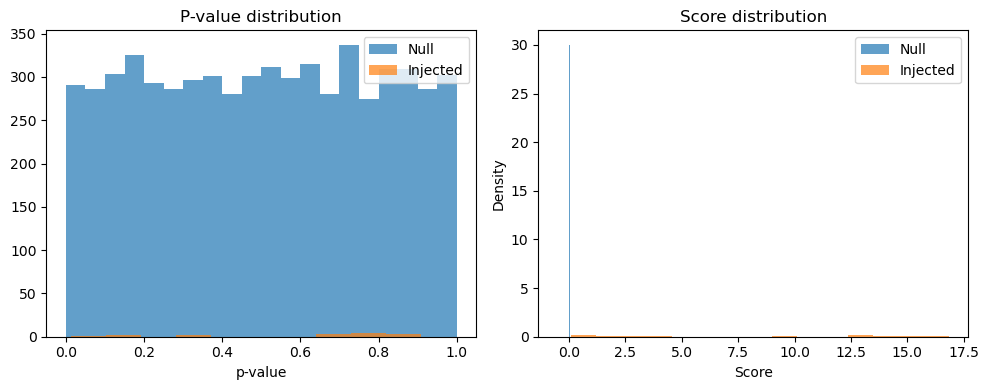

In [5]:
if len(df) > 0 and "ground_truth" in df.columns:
    import matplotlib.pyplot as plt

    # Use first method if grid-run produced multiple methods
    plot_df = df[df["method_id"] == df["method_id"].iloc[0]] if "method_id" in df.columns else df

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    gt = plot_df["ground_truth"]
    if "p_raw" in plot_df.columns:
        axes[0].hist(plot_df.loc[~gt, "p_raw"], bins=20, alpha=0.7, label="Null")
        axes[0].hist(plot_df.loc[gt, "p_raw"], bins=10, alpha=0.7, label="Injected")
        axes[0].set_xlabel("p-value")
        axes[0].set_title("P-value distribution")
        axes[0].legend()
    if "score" in plot_df.columns:
        null_scores = plot_df.loc[~gt, "score"]
        inj_scores = plot_df.loc[gt, "score"]
        axes[1].hist(null_scores, bins=30, alpha=0.7, label="Null", density=True)
        axes[1].hist(inj_scores, bins=15, alpha=0.7, label="Injected", density=True)
        axes[1].set_xlabel("Score")
        axes[1].set_ylabel("Density")
        axes[1].set_title("Score distribution")
        axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot. Run the benchmark first.")